<font color="FF3B3B"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Entrenamiento del modelo más básico</h2></font>

#### David Alejandro Pedroza De Jesús

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import plot_model

In [3]:
drive.mount('/content/drive/')
shutil.copy("/content/drive/MyDrive/kaggle.zip","/content/")
!unzip kaggle.zip
shutil.copy("/content/drive/MyDrive/InfoEspecies.csv","/content/")

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

'/content/InfoEspecies.csv'

# Carga de los datos

In [4]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

In [5]:
def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [6]:
Modificar_direc(train, "train")
Modificar_direc(test, "test")
Modificar_direc(val, "valid")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23452medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22011medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20680medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21100medium.jpg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19837medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23382medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19047medium.jpeg --> Data/val

In [7]:
train_dir = "Data/train"
test_dir = "Data/test"
val_dir = "Data/valid"


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(64, 64),
    batch_size=32,
    label_mode='int'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(64, 64),
    batch_size= 32,
    label_mode='int'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(64, 64),
    batch_size=32,
    label_mode='int'
)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30068 files belonging to 54 classes.
Found 6442 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.


# Creamos el modelo

In [8]:

num_classes = 54


model = models.Sequential()

model.add(layers.Conv2D(num_classes, kernel_size= 3, activation='relu', input_shape=(64, 64, 3)))
model.add(layers.GlobalAveragePooling2D())



model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=100, validation_data=valid_ds)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 106s 109ms/step - accuracy: 0.1474 - loss: 3.5750 - val_accuracy: 0.1423 - val_loss: 3.4686
Epoch 2/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 93s 99ms/step - accuracy: 0.1498 - loss: 3.4422 - val_accuracy: 0.1473 - val_loss: 3.4331
Epoch 3/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.1549 - loss: 3.4142 - val_accuracy: 0.1586 - val_loss: 3.4083
Epoch 4/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.1602 - loss: 3.3913 - val_accuracy: 0.1636 - val_loss: 3.3836
Epoch 5/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.1642 - loss: 3.3698 - val_accuracy: 0.1668 - val_loss: 3.3457
Epoch 6/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.1686 - loss: 3.3494 - val_accuracy: 0.1664 - val_loss: 3.3317
Epoch 7/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.1726 - loss: 3.3325 - val_accuracy: 0.1782 - val_loss: 3.3132
Epoch 8/100
940/940 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.1763 - loss:

In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.4f}")

202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.2965 - loss: 2.9520
Precisión en test: 0.2965


# Arquitectura del modelo

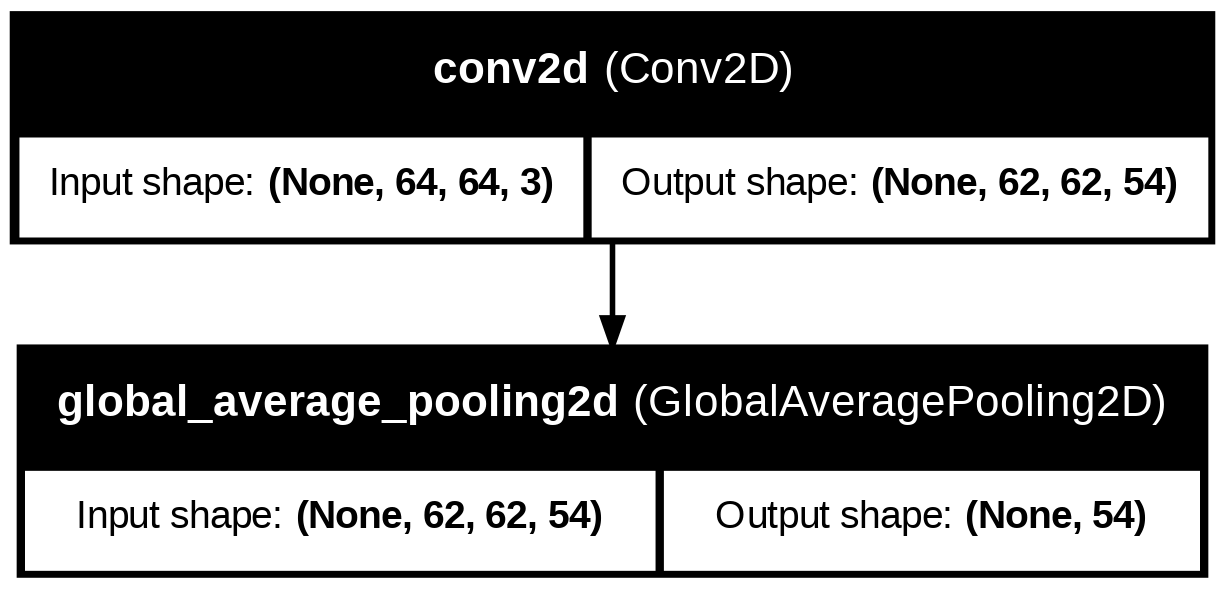

In [18]:
plot_model(model, to_file='modelo.png', show_shapes=True, show_layer_names=True)

# Graficos error

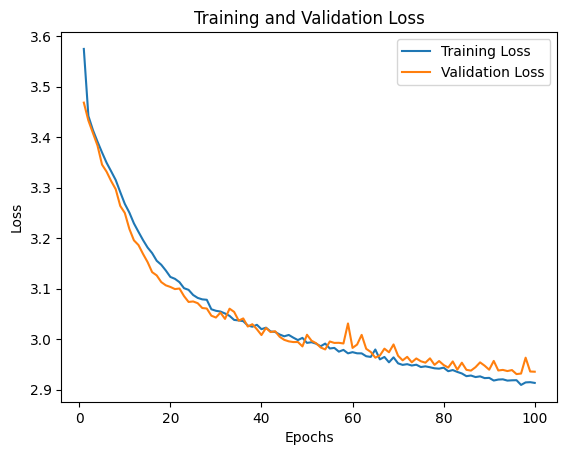

In [11]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(list(range(1,101)),train_loss, label='Training Loss')
plt.plot(list(range(1,101)),val_loss,label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

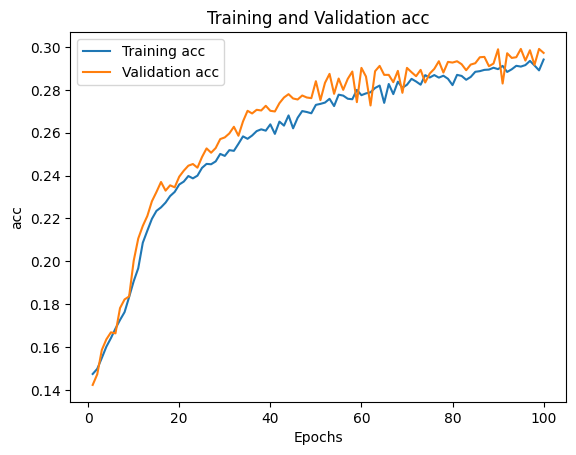

In [12]:
train_loss = history.history['accuracy']
val_loss = history.history['val_accuracy']

plt.plot(list(range(1,101)),train_loss, label='Training acc')
plt.plot(list(range(1,101)),val_loss,label='Validation acc')
plt.legend()
plt.title('Training and Validation acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.show()

# Matriz de confusión

In [13]:
# Inicializar listas
y_true = []
y_pred = []

# Iterar sobre el dataset de prueba
for images, labels in test_ds:
    y_true.extend(labels.numpy())                        # Labels reales
    preds = model.predict(images)                        # Predicciones del modelo
    y_pred.extend(np.argmax(preds, axis=1))              # Clase con mayor probabilidad

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


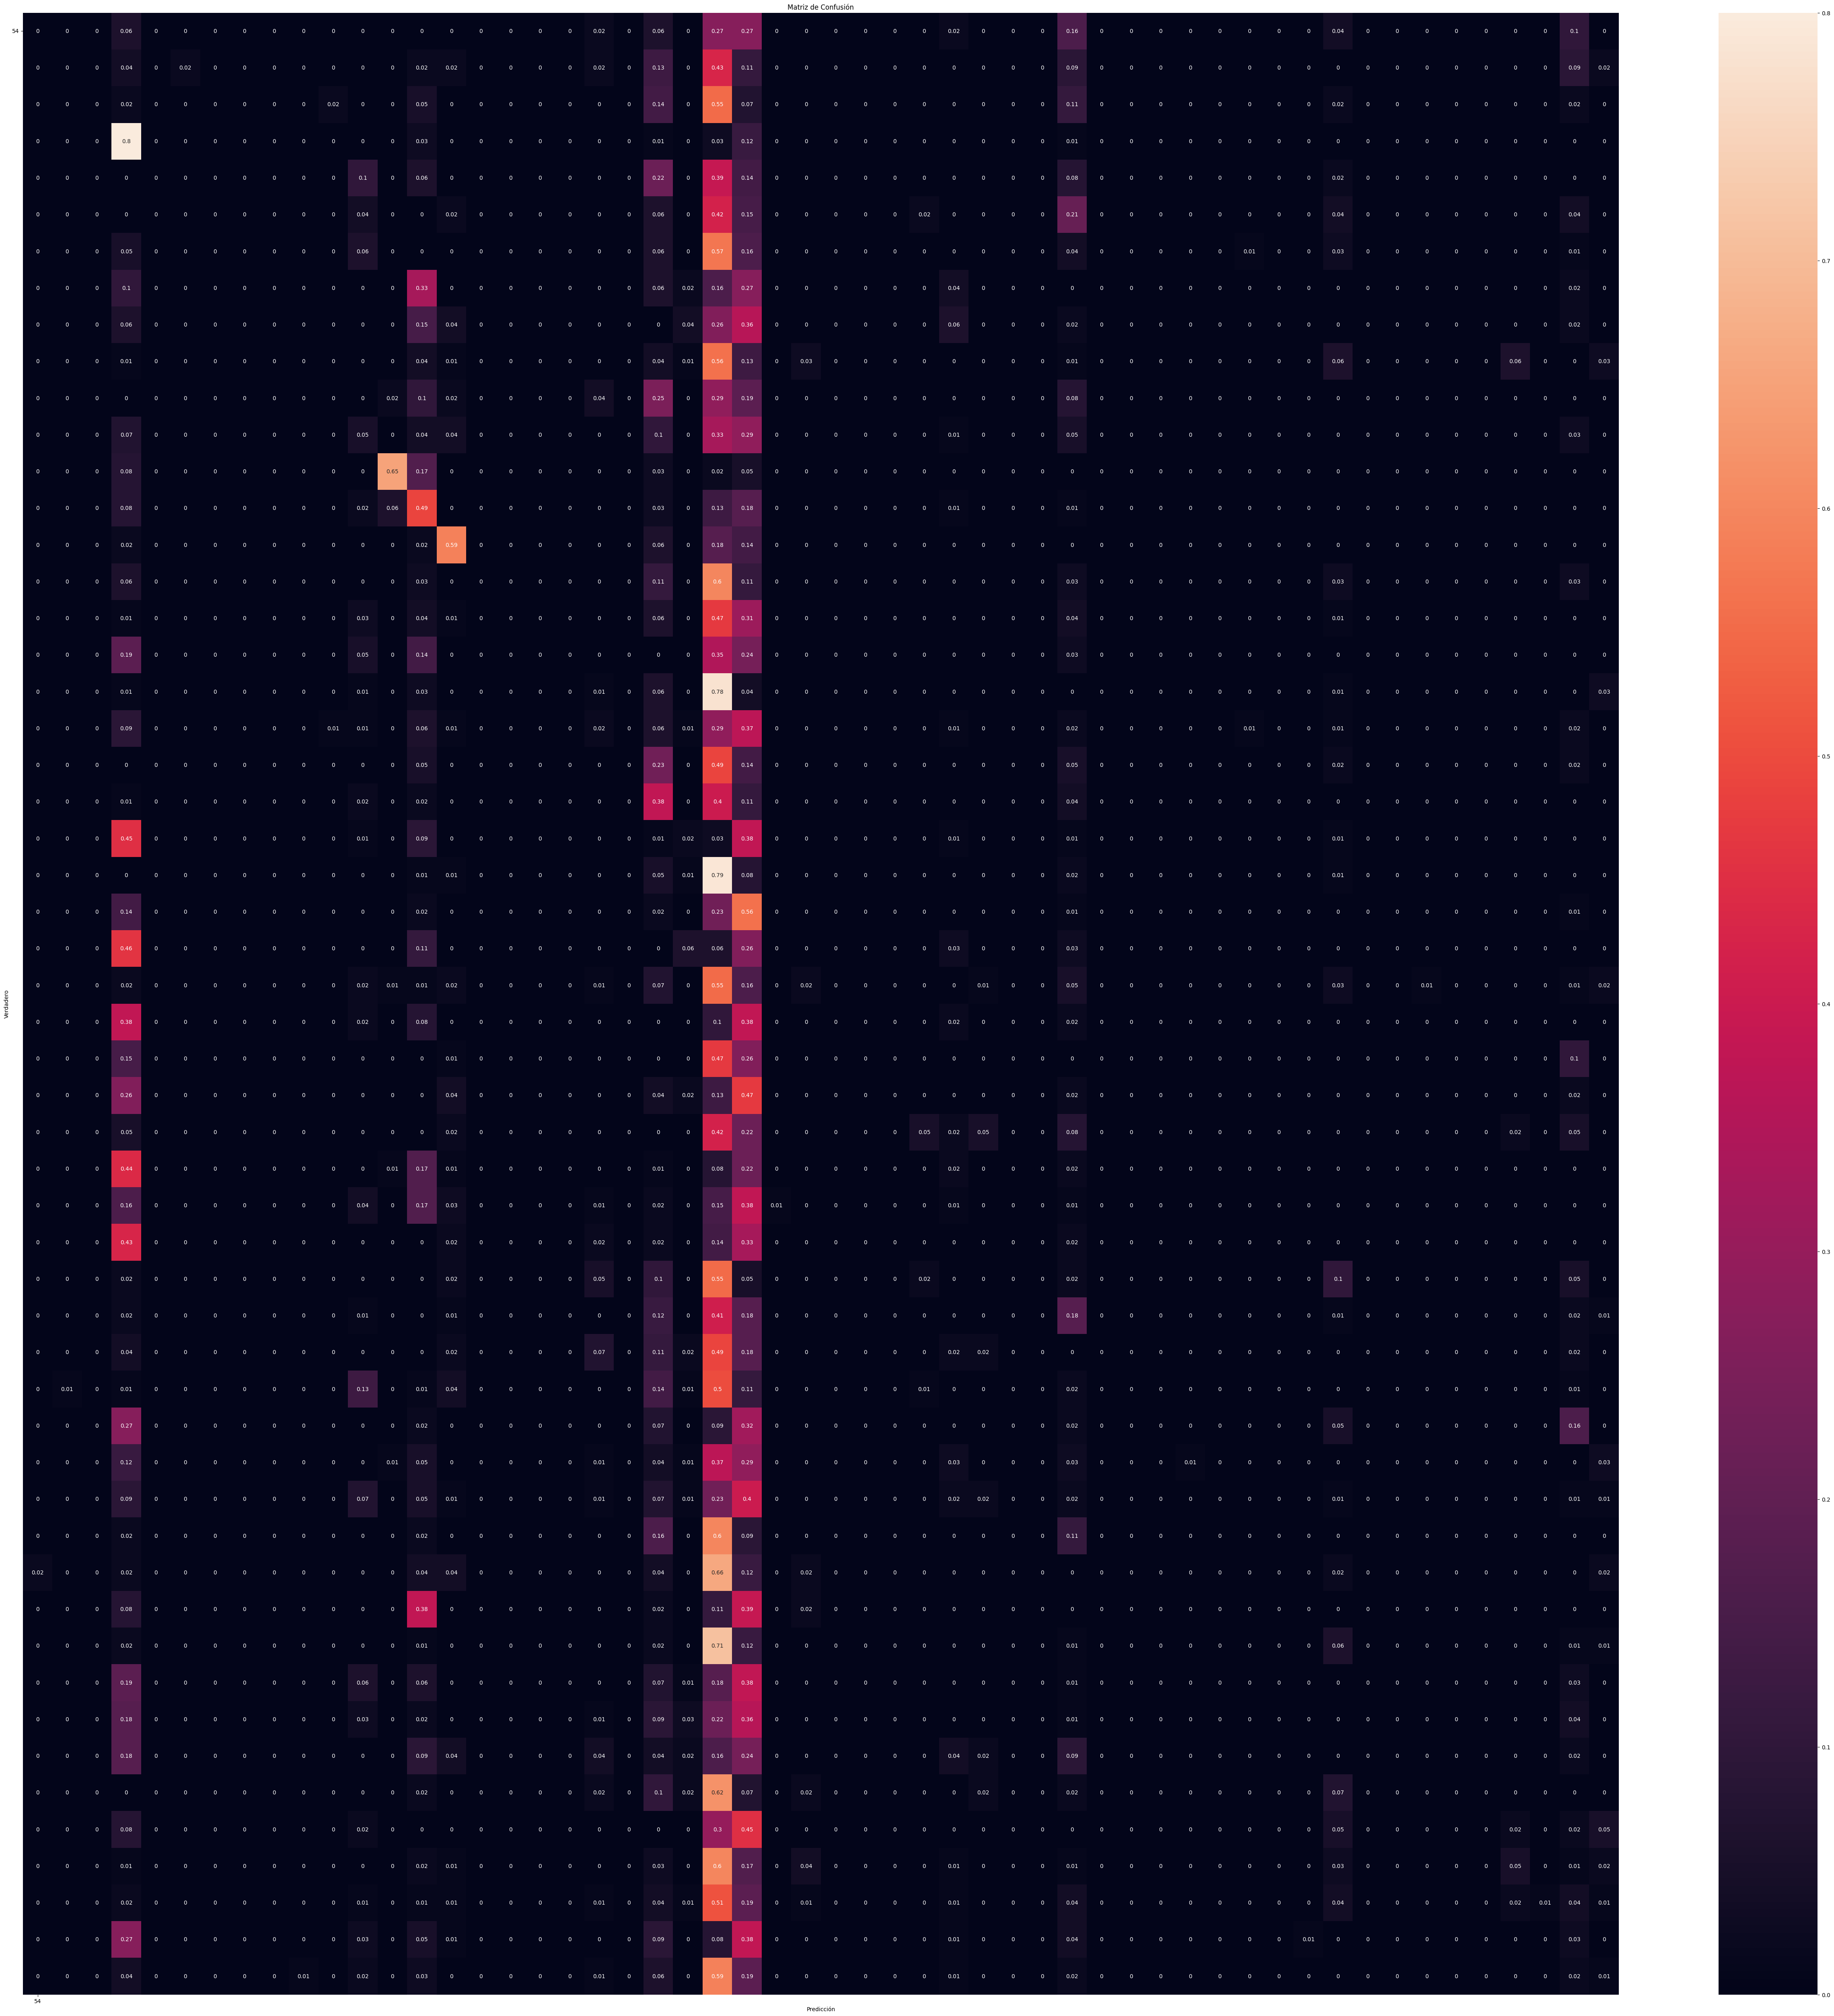

In [14]:
cm = confusion_matrix(y_true,y_pred ,normalize= "true").round(2)
plt.subplots(figsize=(64,64))
sns.heatmap(cm,xticklabels= info_especies.label.shape, yticklabels=info_especies.label.shape,annot=True)
plt.title("Matriz de confución")
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()
plt.show()

In [15]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.00      0.00      0.00        46
           2       0.00      0.00      0.00        44
           3       0.52      0.80      0.63       687
           4       0.00      0.00      0.00        51
           5       0.00      0.00      0.00        48
           6       0.00      0.00      0.00        79
           7       0.00      0.00      0.00        49
           8       0.00      0.00      0.00        53
           9       0.00      0.00      0.00        70
          10       0.00      0.00      0.00        48
          11       0.11      0.05      0.06       220
          12       0.71      0.65      0.68        63
          13       0.20      0.49      0.29       126
          14       0.33      0.59      0.42        51
          15       0.00      0.00      0.00        35
          16       0.00      0.00      0.00        68
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
